In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from dataclasses import dataclass, field, asdict
from typing import List, Dict, Tuple, Optional, Union

import gcsfs
import os
import sys
import json
from pprint import pprint

#fs = gcsfs.GCSFileSystem()
#fs.ls("gs://leap-persistent/sammyagrawal/") # List files in the bucket where the E3SM-MMF dataset is stored

In [2]:
sys.path.append(os.path.abspath(os.path.join('../diffusionsim')))
import torch
import torch.nn as nn
import xbatcher
import torch.nn.functional as F

import diffusers
import diffusionsim as diff
import diffusionsim.training_utils as tru
from diffusionsim.climsim_utils import imagify
from diffusionsim import mydatasets as data
#import diffusionsim.evaluations as evals

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [3]:
diffusers.__file__

'/home/jovyan/Samarth/GenAI Playground/diffusers/src/diffusers/__init__.py'

In [4]:
torch.manual_seed(0)
np.random.seed(0)

## Data

In [5]:
source = "local-vzarr" if False else "gcsfs"

dconfig = tru.my_dconfig(source, "v1", in_notebook=True, shuffle_indices=False, 
                        dataset_type="climsim", batch_size=64, use_tendencies=False)
dconfig.train_test_split = [1.0]
pprint(dconfig)

DataConfig(dataset_type='climsim',
           climsim_type='low-res-expanded',
           source='gcsfs',
           data_dir='/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests',
           train_test_split=[1.0],
           dataloader_params=DataLoaderParams(batch_size=24576,
                                              shuffle=True,
                                              num_workers=0,
                                              prefetch_factor=None,
                                              persistent_workers=False,
                                              multiprocessing_context=None,
                                              pin_memory=True),
           data_vars='v1',
           use_tendencies=False,
           norm_info='image',
           chunksize={},
           log_batching=True,
           shuffle_indices=False)


In [6]:
dataloaders, [indices] = data.load_dataloaders(dconfig, log=False, indices=None)

In [7]:
dl = dataloaders[0]
ds = dl.dataset

In [8]:
x, y = next(iter(dl))
## imagify(x, ds.dutils, 'x', 1).shape

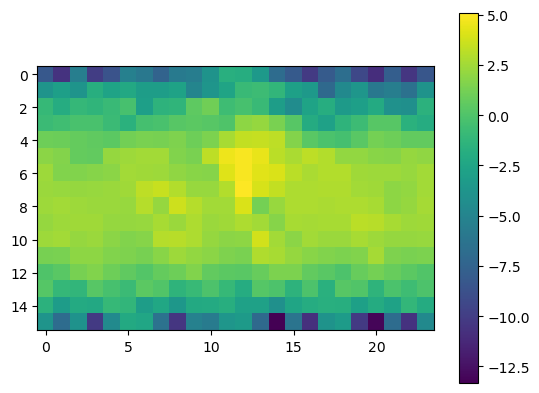

In [9]:
plt.imshow(imagify(y, ds.dutils, 'y', 2)[0, 59].cpu().detach().numpy())
plt.colorbar()

In [10]:
def plot_profile(data, var_index=None, ax=None, title='', **kwargs):
    data = np.asarray(data)
    assert data.ndim < 4, "no more than 3d"
    if data.ndim == 3:
        assert var_index is not None, "need to specify variable"
        data = data[:, var_index, :]
    elif(data.ndim == 2 and data.shape[0] == 10):
        data = data[var_index]
    levels = np.arange(data.shape[-1])
    if ax is None:
        fig, ax = plt.subplots()
    if data.ndim == 1:
        ax.plot(data, levels, **kwargs)
    else:
        for profile in data: 
            ax.plot(profile, levels, **kwargs) 
    ax.invert_yaxis()
    ax.set_ylabel("Level index (0 = top)")
    ax.set_title(title)
    if var_index is not None: 
        ax.set_xlabel(ds.target_vars[var_index])

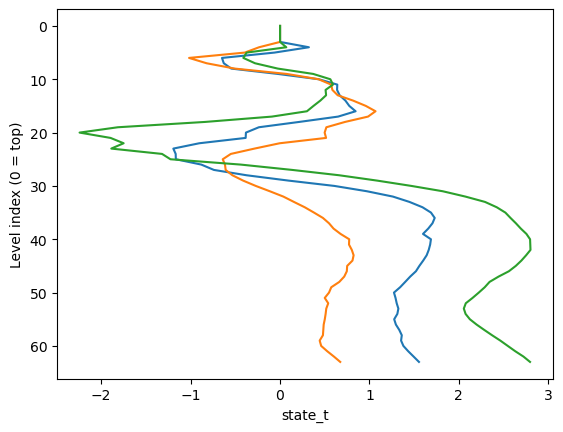

In [11]:
plot_profile(imagify(y, ds.dutils, 'y', 1)[0:3], 0)

# How Diffusion Works

### Sampling $x_t$ from markov chain
[DDPM Paper](https://arxiv.org/pdf/2006.11239)
Given a **fixed** noise schedule $\{\beta_1, ..., \beta_T\}$, we can define $\alpha_t:= 1- \beta_t$ and $\bar{\alpha_t} = \prod_{s=1}^t \alpha_s$

Giving rules for products of gaussians, we can conveniently sample from any arbitrary node in the Markov Chain as long as we condition on $x_0$. $$q(x_t|x_0) = \mathcal N(\sqrt{\bar{\alpha_t}} \cdot x_0, (1-\bar{\alpha_t}) I)$$

Given a sample $\epsilon$ drawn from a standard gaussian, we leverage this to reparameterize $$x_t(x_0, \epsilon) = \sqrt{\bar{\alpha_t}} \cdot x_0 + \sqrt{1-\bar{\alpha_t}} \cdot \epsilon$$


The loss, which can also be interpreted as training a noise-conditional score based model, is (14) from the paper: $$L_{simple} := \mathbb{E} [||\epsilon - \epsilon_\theta(x_t(x_0, \epsilon, t), t)||^2]$$

In [ ]:
IMAGE_DIM = 1
input_sample = imagify(y, ds.dutils, 'y', IMAGE_DIM)
input_sample.shape

In [ ]:
train_steps = 100

In [ ]:
scheduler_type = "ddpm" 
scheduler_params = tru.SchedulerParams(num_train_timesteps=train_steps)
scheduler_params

In [ ]:
scheduler_class = diffusers.DDPMScheduler if scheduler_type=="ddpm" else diffusers.DDIMScheduler
noise_scheduler = scheduler_class(**asdict(scheduler_params))

In [ ]:

scheduler = diffusers.DDPMScheduler(
    num_train_timesteps=100,
    beta_start=0.0001,
    beta_end=0.1,  # Changed from 0.01 to 0.2
    beta_schedule="linear",
)
scheduler2 = diffusers.DDPMScheduler(
    num_train_timesteps=100,
    beta_start=0.0001,
    beta_end=0.2,  # Changed from 0.01 to 0.2
    beta_schedule="linear",
)
plt.plot(scheduler.betas) # how much noise
plt.plot(scheduler2.betas)
plt.plot(scheduler.alphas_cumprod, label='alpha_bar') # how much signal vs noise
plt.plot(scheduler2.alphas_cumprod, label='alpha_bar2')
plt.legend()
plt.show()

In [ ]:
print(noise_scheduler.config.num_train_timesteps)
print(noise_scheduler.timesteps)
noise_scheduler.set_timesteps(10)
print(noise_scheduler.timesteps)
noise_scheduler.set_timesteps(100)

In [ ]:
def get_alpha_t_manual(t, scheduler=noise_scheduler):
    a = 1
    for s in range(t+1):
        a = a * (1-scheduler.betas[s])
    return(a)
print(get_alpha_t_manual(5) - noise_scheduler.alphas_cumprod[5])
noise_scheduler.alphas_cumprod[:6]

In [ ]:
fig, axes = plt.subplots(1, 2, sharex=True)
axes[1].plot(noise_scheduler.alphas_cumprod, label='alpha_bar')
axes[0].plot(noise_scheduler.betas, label='betas', color='orange')
plt.legend()
plt.show()

In [ ]:
def sample_xt(x0, t):
    eps = torch.randn(x0.shape) # BS x C x H x W
    xt = noise_scheduler.add_noise(x0, eps, torch.LongTensor(t)) # noisy image
    return(xt, eps)

In [ ]:
t = 50
x50, eps = sample_xt(input_sample, [t])

In [ ]:
at = noise_scheduler.alphas_cumprod[t]
x50_manual = torch.sqrt(at) * input_sample + torch.sqrt(1-at)*eps

In [ ]:
loss_fn = torch.nn.MSELoss()

In [ ]:
(x50_manual == x50).all() # the same! 

Loss called to match model prediction to actual noise used to generate noisy latent. 

training_loss = loss_fn(model(x_t, t).sample, epsilon_noise_sample)

In [ ]:
eps.shape, input_sample.shape

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
var_index = 0
if IMAGE_DIM == 1:
    
    plot_profile(input_sample[0, var_index], ax=axes[0], title="Original", )
    
    plot_profile(x50[0, var_index], ax=axes[1], title="Noisy", var_index=0)
    
    plot_profile(eps[0, var_index], ax=axes[2], title="Noise", var_index=0)
    
    plt.tight_layout()
    plt.show()
elif IMAGE_DIM == 2:
    im0 = axes[0].imshow(input_sample.permute(0, 2, 3, 1).cpu().numpy()[0, :, :, 59], 'viridis')
    axes[0].title.set_text("x0 original sample")
    axes[0].set_axis_off()
    
    im1 = axes[1].imshow(x50.permute(0, 2, 3, 1).cpu().numpy()[0, :, :, 59], 'viridis')
    axes[1].set_axis_off()
    axes[1].title.set_text("x50 noisy sample")
    
    im2 = axes[2].imshow(eps[0, 59, :, :], 'viridis')
    axes[2].set_axis_off()
    axes[2].title.set_text("Noise Level eps")
    
    fig.colorbar(im0, ax=axes[0], orientation='vertical')
    fig.colorbar(im1, ax=axes[1], orientation='vertical')
    fig.colorbar(im2, ax=axes[2], orientation='vertical')
    plt.show()

In [ ]:
x100, eps = sample_xt(input_sample, [99])

In [ ]:
if IMAGE_DIM == 1:
    plot_profile(x100[26, var_index], color='orange')
else:
    plt.imshow(x100[0, 59])

### How much Noise Destroys Sample? 

$$ \mathbb{E}[(X+\epsilon)^T (X+\epsilon)] = \mathbb{E}[(X^T X +\epsilon^T \epsilon)]$$
$$ = V \Lambda V^{-1} + V \sigma^2 I V^{-1} = V (\Lambda + \sigma^2 I) V^{-1}$$

In [ ]:
print(input_sample.shape)

X = input_sample.reshape(128, -1)
X.shape

In [ ]:
plt.hist(X.flatten())

In [ ]:
M = torch.matmul(X, torch.transpose(X, 0, 1)).numpy()
print(f"M symmetric: {np.isclose(M, M.T).all()}")
M.shape

In [ ]:
eig, Q = np.linalg.eigh(M)

In [ ]:
Mhat = np.dot(np.dot(Q, np.diag(eig)), Q.T)

plt.imshow(Mhat - M)
plt.colorbar()

In [ ]:
eig[-5:]

These eigenvalues seem really high...

## How Reverse Diffusion with trained model works

Given $\epsilon$, we can obtain the distribution for a reverse diffusion step. Recall that $$p_\theta(x_{t-1} | x_t) := \mathcal{N}(x_{t-1}; \mu_\theta(x_t, t), \Sigma_\theta=\sigma_t^2 I)$$
where $\sigma_t^2=\beta_t$ is a common choice. 


$$x_{t-1} =\dfrac{1}{\alpha_t}\left(x_t - \dfrac{\beta_t}{\sqrt{1-\alpha_t}} \epsilon_\theta(x_t, t)\right) + \sigma_t z \,\,\,\,\,\, z \sim \mathcal N(0, I)$$

More simply, since $x_t = \sqrt{1 - \beta_t} x_{t-1} + \sqrt{\beta_t} \sigma_t$, then $x_{t-1} = \dfrac{1}{\alpha_t}(x_t - \sqrt{\beta_t} \epsilon_\theta)$

In [ ]:
noise_scheduler.timesteps

In [ ]:
x50.shape, eps.shape

In [ ]:
gen = torch.Generator()

In [ ]:
x49 = noise_scheduler.step(eps, timestep=50, sample=x50, generator=gen).prev_sample
x49.shape

In [ ]:
x49b = noise_scheduler.step(eps, timestep=50, sample=x50, generator=gen).prev_sample

In [ ]:
sigma_diff = (x49 - x49b).numpy() / np.sqrt(noise_scheduler.betas[50])
print(sigma_diff.shape)
if IMAGE_DIM == 1:
    plot_profile(sigma_diff[0,0])
else:
    plt.imshow(sigma_diff[0,59,:,:]/2)
    plt.colorbar()

In [ ]:
def manual_inference_step(epsilon, t, xt, scheduler):
    # x t-1
    bt = noise_scheduler.betas[t]
    x = xt - np.sqrt(bt) * epsilon
    x = x / np.sqrt(1 - bt)
    return(x)

In [ ]:
def run_pipeline(model, scheduler):
    # get x t-1 given x_t
    input =  torch.randn(input_sample.shape)
    for t in scheduler.timesteps:
        with torch.no_grad():
            noisy_residual = model(input, t).sample
        previous_noisy_sample = scheduler.step(noisy_residual, t, input).prev_sample
        input = previous_noisy_sample


In [ ]:
x49_manual = manual_inference_step(eps, 50, x50, noise_scheduler)

In [ ]:
x49_manual.shape

# U Net Model

Ok so we have our noisy dataset and our well defined task. Let's explore the model!

- U Net at its core is a convolution based encoder decoder architecture that progressively reduces height/width dimensionality but adds channels with "down blocks" and rescales with "upblocks". Residual connections as well
- Timestep is fed into noise-conditional model via a time embedding. "temb" is a parameter in all the downsample blocks


Resources: 
- [Time Embeddings and conditioning](https://varun-ml.github.io/posts/diffusion-models/denoising-diffusion-models-2/)

In [5]:
import inspect
def pass_config(func, data_class):
    # only pass model config params that function takes in
    accepted_params = inspect.signature(func).parameters
    filtered_kwargs = {k: v for k, v in asdict(data_class).items() if k in accepted_params}
    return func(**filtered_kwargs)

## 1D Diffusion

[Source code](https://github.com/huggingface/diffusers/blob/v0.34.0/src/diffusers/models/unets/unet_1d.py#L41)

[Projection Embedding src](https://github.com/huggingface/diffusers/blob/main/src/diffusers/models/embeddings.py#L1321)

In [6]:
img = torch.randn(8, 10, 64).to(device) # imagify(y, ds.dutils, 'y', 1).to(device)
img.shape, img.device

(torch.Size([8, 10, 64]), device(type='cuda', index=0))

In [7]:
@dataclass
class DiffusionModelConfig1d:
    in_channels: int = 10
    out_channels: int = 10
    down_block_types: Tuple[str] = ("DownResnetBlock1D", "AttnDownBlock1D", "DownBlock1D")
    up_block_types: Tuple[str] = ("UpResnetBlock1D", "AttnUpBlock1D", "UpBlock1D")
    norm_num_groups: int = 8
    layers_per_block: int = 1
    act_fn: str = "silu" # https://github.com/huggingface/diffusers/blob/main/src/diffusers/models/activations.py#L27
    freq_shift: float = 0.0 # fourier freq shift
    use_timestep_embedding: bool = True
    block_out_channels: Tuple[int] = (32, 32, 64) # (32, 32, 64
    extra_in_channels: int = 0

unet_params = DiffusionModelConfig1d()
pprint(unet_params)

DiffusionModelConfig1d(in_channels=10,
                       out_channels=10,
                       down_block_types=('DownResnetBlock1D',
                                         'AttnDownBlock1D',
                                         'DownBlock1D'),
                       up_block_types=('UpResnetBlock1D',
                                       'AttnUpBlock1D',
                                       'UpBlock1D'),
                       norm_num_groups=8,
                       layers_per_block=1,
                       act_fn='silu',
                       freq_shift=0.0,
                       use_timestep_embedding=True,
                       block_out_channels=(32, 32, 64),
                       extra_in_channels=0)


In [8]:
diff.models.ClimsimUNet1DModel

diffusionsim.models.ClimsimUNet1DModel

In [20]:
unet = pass_config(diff.models.ClimsimUNet1DModel, unet_params)
self = unet

In [23]:
self.device

device(type='cpu')

In [49]:
unet(sample, 0).sample.shape, sample.shape

(torch.Size([8, 10, 64]), torch.Size([8, 10, 64]))

### Forward Pass

self.time_proj is defined [here](https://github.com/huggingface/diffusers/blob/main/src/diffusers/models/embeddings.py#L1321)

self.time_mlp is defined [here](https://github.com/huggingface/diffusers/blob/main/src/diffusers/models/embeddings.py#L1254)

Hardcoded values worth looking at: [source code](https://github.com/huggingface/diffusers/blob/v0.34.0/src/diffusers/models/unets/unet_1d.py#L41)

1. Why is the embedding size for the GaussianFourierProjection always 8? --> forces block_out_channels[0] to be 8
2. Play 

In [46]:
sample = img.to("cpu")
sample.shape, sample.device

(torch.Size([8, 10, 64]), device(type='cpu'))

In [26]:
timesteps = torch.tensor([1, 7, 4, 8], dtype=torch.long)
timesteps[:,None].shape

timestep = 0
timesteps = timestep
if not torch.is_tensor(timesteps):
    timesteps = torch.tensor([timesteps], dtype=torch.long, device=sample.device)
elif torch.is_tensor(timesteps) and len(timesteps.shape) == 0:
    timesteps = timesteps[None].to(sample.device)

timesteps

tensor([0])

In [27]:
timestep_embed = self.time_proj(timesteps)
print(self.time_proj.weight.shape)  # GaussianFP(embedding_size=block_out_channels[0], scale=1.0) 
timestep_embed.shape # 2 times the weight, cat[sin, cos]

torch.Size([32])


torch.Size([1, 64])

In [28]:
if True and self.config.use_timestep_embedding:
    timestep_embed = self.time_mlp(timestep_embed.to(sample.dtype)) # (in=timestep.input_dim = block_out_channels[0], out=block_out_channels[0]
else:
    timestep_embed = timestep_embed[..., None] # [1, C, 1]
    timestep_embed = timestep_embed.repeat([1, 1, sample.shape[2]]).to(sample.dtype) # [1, C, lev 64]
timestep_embed = timestep_embed.broadcast_to((sample.shape[:1] + timestep_embed.shape[1:])) # [N, C, 64]
timestep_embed.shape

torch.Size([8, 32])

In [29]:
i, j = 2, 6
timestep_embed[i] == timestep_embed[j]

tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True])

In [30]:
temb = timestep_embed
sample.shape, timestep_embed.shape

(torch.Size([8, 10, 64]), torch.Size([8, 32]))

In [31]:
sample.device

device(type='cpu')

In [32]:
# 2. down
down_block_res_samples = ()
for downsample_block in self.down_blocks:
    sample, res_samples = downsample_block(hidden_states=sample, temb=timestep_embed)
    print(sample.shape, type(res_samples), len(res_samples), res_samples[0].shape)
    down_block_res_samples += res_samples

torch.Size([8, 32, 32]) <class 'tuple'> 1 torch.Size([8, 32, 32])
torch.Size([8, 32, 16]) <class 'tuple'> 1 torch.Size([8, 32, 16])
torch.Size([8, 64, 8]) <class 'tuple'> 1 torch.Size([8, 64, 8])


In [33]:
print((sample == res_samples[0]).all())
sample.shape, res_samples[0].shape

tensor(True)


(torch.Size([8, 64, 8]), torch.Size([8, 64, 8]))

In [34]:
print(len(down_block_res_samples))
for i in down_block_res_samples:
    print(i.shape)

3
torch.Size([8, 32, 32])
torch.Size([8, 32, 16])
torch.Size([8, 64, 8])


In [40]:
sample = self.mid_block(sample, timestep_embed)

In [41]:
sample.shape, down_block_res_samples[-1].shape, type(self.up_blocks[0])

(torch.Size([8, 64, 8]),
 torch.Size([8, 64, 8]),
 diffusionsim.blocks_1d.UpResnetBlock1D)

In [42]:
self.up_blocks[1].resnets[1]

ResConvBlock(
  (conv_1): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (group_norm_1): GroupNorm(1, 32, eps=1e-05, affine=True)
  (gelu_1): GELU(approximate='none')
  (conv_2): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (group_norm_2): GroupNorm(1, 32, eps=1e-05, affine=True)
  (gelu_2): GELU(approximate='none')
)

In [43]:
sample_test = self.up_blocks[0](sample, res_hidden_states_tuple=down_block_res_samples[-1:], temb=timestep_embed).detach().cpu().clone()
down_block_res_samples_test = down_block_res_samples[:-1]

In [44]:
sample_test.shape, len(down_block_res_samples_test), down_block_res_samples_test[-1].shape

(torch.Size([8, 32, 16]), 2, torch.Size([8, 32, 16]))

In [222]:
sample_test2 = self.up_blocks[1].to('cpu')(sample_test, res_hidden_states_tuple=res_sample_test, temb=timestep_embed.to('cpu')).detach().cpu().clone()
down_block_res_samples_test2 = down_block_res_samples_test[:-1]
res_sample_test2 = (down_block_res_samples_test2[-1].to("cpu"),)

In [225]:
len(res_sample_test2), res_sample_test2[0].shape, sample_test2.shape

(1, torch.Size([8, 32, 64]), torch.Size([8, 32, 32]))

In [231]:
(res_sample_test2[0] == down_block_res_samples[0].to("cpu")).all()

tensor(True)

In [164]:
sample_test.shape, sample_test2.shape

(torch.Size([8, 32, 16]), torch.Size([8, 32, 32]))

In [234]:
self.down_blocks[0]

DownResnetBlock1D(
  (resnets): ModuleList(
    (0): ResidualTemporalBlock1D(
      (conv_in): Conv1dBlock(
        (conv1d): Conv1d(10, 32, kernel_size=(5,), stride=(1,), padding=(2,))
        (group_norm): GroupNorm(8, 32, eps=1e-05, affine=True)
        (mish): Mish()
      )
      (conv_out): Conv1dBlock(
        (conv1d): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
        (group_norm): GroupNorm(8, 32, eps=1e-05, affine=True)
        (mish): Mish()
      )
      (time_emb_act): Mish()
      (time_emb): Linear(in_features=32, out_features=32, bias=True)
      (residual_conv): Conv1d(10, 32, kernel_size=(1,), stride=(1,))
    )
    (1): ResidualTemporalBlock1D(
      (conv_in): Conv1dBlock(
        (conv1d): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
        (group_norm): GroupNorm(8, 32, eps=1e-05, affine=True)
        (mish): Mish()
      )
      (conv_out): Conv1dBlock(
        (conv1d): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))

In [165]:
sample_test3 = self.up_blocks[2](sample_test2, res_hidden_states_tuple=down_block_res_samples_test2[-1:], temb=timestep_embed)
down_block_res_samples_test3 = down_block_res_samples_test2[:-1]

RuntimeError: Sizes of tensors must match except in dimension 1. Expected size 32 but got size 64 for tensor number 1 in the list.

In [148]:
sample_test = sample.cpu().detach().clone()
res_samples_test = (res_samples[0].cpu().detach().clone(),)
down_block_res_samples_test = (down_block_res_samples[0].cpu().detach().clone(),)

In [103]:
bad_block = self.up_blocks[2].to("cpu")
bad_block

UpBlock1D(
  (resnets): ModuleList(
    (0): ResConvBlock(
      (conv_skip): Conv1d(64, 32, kernel_size=(1,), stride=(1,), bias=False)
      (conv_1): Conv1d(64, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (group_norm_1): GroupNorm(1, 32, eps=1e-05, affine=True)
      (gelu_1): GELU(approximate='none')
      (conv_2): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (group_norm_2): GroupNorm(1, 32, eps=1e-05, affine=True)
      (gelu_2): GELU(approximate='none')
    )
    (1): ResConvBlock(
      (conv_1): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (group_norm_1): GroupNorm(1, 32, eps=1e-05, affine=True)
      (gelu_1): GELU(approximate='none')
      (conv_2): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (group_norm_2): GroupNorm(1, 32, eps=1e-05, affine=True)
      (gelu_2): GELU(approximate='none')
    )
    (2): ResConvBlock(
      (conv_skip): Conv1d(32, 10, kernel_size=(1,), stride=(1,), bias=False)
      (co

In [149]:
#sample = bad_block(sample_test, res_hidden_states_tuple=res_samples_test, temb=timestep_embed.to("cpu"))

In [107]:
res_hidden_states_tuple = res_samples_test
temb = timestep_embed.to("cpu")
hidden_states = sample_test

In [108]:
res_hidden_states = res_hidden_states_tuple[-1]
hidden_states = torch.cat([hidden_states, res_hidden_states], dim=1)

RuntimeError: Sizes of tensors must match except in dimension 1. Expected size 32 but got size 16 for tensor number 1 in the list.

In [110]:
hidden_states.shape, res_hidden_states.shape

(torch.Size([8, 32, 32]), torch.Size([8, 32, 16]))

## 2D Diffusion

In [ ]:
@dataclass
class DiffusionModelConfig:
    model_type: str = "diffusion"
    image_height = 16
    image_width  = 24
    in_channels: int = 128
    latent_dims: int = 16
    out_channels: int = 128
    block_out_channels: Tuple = field(default_factory=lambda: (32, 64, 64, 128))  # num output channel for each UNet block
    down_blocks: Tuple = field(default_factory=lambda: (
        "DownBlock2D",  # a regular ResNet downsampling block
        "DownBlock2D",
        "AttnDownBlock2D",  # a ResNet downsampling block with spatial self-attention
        "DownBlock2D",
    ))
    up_blocks: Tuple = field(default_factory=lambda: (
        "UpBlock2D",  # a regular ResNet upsampling block
        "AttnUpBlock2D",  # a ResNet upsampling block with spatial self-attention
        "UpBlock2D",
        "UpBlock2D",
    ))

In [ ]:
unet = tru.UNetParams()
unet.block_out_channels = (128, 256, 512)
unet.down_block_types = ("DownBlock2D", "AttnDownBlock2D", "DownBlock2D")
unet.up_block_types = ("UpBlock2D", "AttnUpBlock2D", "UpBlock2D")
unet.layers_per_block = 1
unet.norm_num_groups = 2

In [ ]:
scheduler = tru.SchedulerParams()

In [ ]:
mconfig = tru.ModelConfig()
mconfig.model_type = "ddpm_diffusion"
mconfig.unet = unet
mconfig.scheduler = scheduler
pprint(asdict(mconfig))

#### Regular Model (no latent space)

In [ ]:
mconfig = DiffusionModelConfig()
mconfig

In [ ]:
model = load_model(mconfig, device)

In [ ]:
#print(isinstance(layers[1], diffusers.models.embeddings.Timesteps))
t = torch.tensor([1, 2, 3, 4])

In [ ]:
input_sample.device

In [ ]:
output = model(input_sample.to(device), timestep=0)
output.sample.shape

In [ ]:
plt.imshow(output.sample[0].cpu().detach().numpy()[59])
plt.title(f"Predicted {train_ds.mlo[59].item()}")
plt.colorbar()
plt.show()

## Latent Diffusion

Following diffusers [source code](https://github.com/huggingface/diffusers/blob/main/src/diffusers/models/unets/unet_2d.py#L243)

In [ ]:
class UnconditionalDiffusion(nn.Module):
    def __init__(self, encoder, decoder, unet):
        self.encoder = encoder
        self.decoder = decoder
        self.unet = unet

    def forward(self, noisy_sample):
        noisy_latent = self.encoder(noisy_sample)
        denoised_latent = self.unet(noisy_latent)
        denoised_sample = self.decoder(denoised_latent)

        return(denoised_sample)

In [ ]:
lconfig = DiffusionModelConfig()
lconfig.model_type = "latent_diffusion"
lconfig.block_out_channels = (32, 64)
lconfig.down_blocks = ("DownBlock2D", "DownBlock2D")
lconfig.up_blocks = ("UpBlock2D", "UpBlock2D")

In [ ]:
ldm = load_model(lconfig, device)

In [ ]:
input_sample = torch.randn(4, 16, 16, 24)
ts = [5, 8, 2, 6]

#### How the time embeddings work: 

In [ ]:
def time_embed_fwd(self,
    sample: torch.Tensor,
    timestep: Union[torch.Tensor, float, int],
    class_labels: Optional[torch.Tensor] = None,
    ) -> Tuple:
    timesteps = timestep
    if not torch.is_tensor(timesteps):
        timesteps = torch.tensor([timesteps], dtype=torch.long, device=sample.device)
    elif torch.is_tensor(timesteps) and len(timesteps.shape) == 0:
        timesteps = timesteps[None].to(sample.device)

    # broadcast to batch dimension in a way that's compatible with ONNX/Core ML
    timesteps = timesteps * torch.ones(sample.shape[0], dtype=timesteps.dtype, device=timesteps.device)
    t_emb = self.time_proj(timesteps)

    # timesteps does not contain any weights and will always return f32 tensors
    # but time_embedding might actually be running in fp16. so we need to cast here.
    # there might be better ways to encapsulate this.
    t_emb = t_emb.to(dtype=self.dtype)
    emb = self.time_embedding(t_emb)
    
    if self.class_embedding is not None:
        if class_labels is None:
            raise ValueError("class_labels should be provided when doing class conditioning")

        if self.config.class_embed_type == "timestep":
            class_labels = self.time_proj(class_labels)
        class_emb = self.class_embedding(class_labels).to(dtype=self.dtype)
        emb = emb + class_emb
    elif self.class_embedding is None and class_labels is not None:
        raise ValueError("class_embedding needs to be initialized in order to use class conditioning")
    return(timesteps, t_emb, emb)

[source code](https://github.com/huggingface/diffusers/blob/main/src/diffusers/models/embeddings.py)

1. First the timesteps are processed to ensure that they match the batch size, meaning we have N proper copies of model(x_t, t).
2. The Timesteps class calls get_timestep_embedding which creates sinusoidal embeddings (something something sin-cos of $e^{f(t)}$). For each timestep, creates a 32 dimensional positional embedding
3. From these 32 dim time_embedding vectors, the model's TimestepEmbedding is a learned nn.Module that further projects the embedding into a final 128 dimensional embedding. Presumably this is a learned projection.

Eventually, these conditioned embeddings are fit into our blocks

In [ ]:
type(ldm.time_proj), type(ldm.time_embedding)

In [ ]:
ldm.time_embedding

In [ ]:
timesteps, temb, emb = time_embed_fwd(ldm, sample, timestep=torch.tensor(ts))

In [ ]:
temb.shape, emb.shape # both are torch tensors

In [ ]:
for i in range(4):
    plt.plot(temb[i])
plt.title("32 dim temb embeddings")
plt.show()

In [ ]:
emb = emb.detach().numpy()
for i in range(4):
    plt.plot(emb[i])

plt.title("128 dim emb embeddings")
plt.show()

In [ ]:
ldm.time_proj

#### How the down blocks work

In [ ]:
timesteps, temb, emb = time_embed_fwd(ldm, sample, timestep=torch.tensor(ts))

In [ ]:
skip_sample = input_sample
sample = ldm.conv_in(input_sample)

skip_sample.shape, sample.shape

In [ ]:
def down_blocks_fwd(self, sample: torch.Tensor, emb, skip_sample, ) -> Tuple:
    down_block_res_samples = (sample,)
    for downsample_block in self.down_blocks:
        if hasattr(downsample_block, "skip_conv"):
            sample, res_samples, skip_sample = downsample_block(
                hidden_states=sample, temb=emb, skip_sample=skip_sample
            )
        else:
            sample, res_samples = downsample_block(hidden_states=sample, temb=emb)

        down_block_res_samples += res_samples
    return(sample, res_samples, skip_sample, down_block_res_samples)
    

In [ ]:
(1,) + (2,) # tuple addition is concat; down_block_res_samples stores all res blocks

In [ ]:
sample, res_samples, skip_sample, down_block_res_samples = down_blocks_fwd(ldm, sample, emb, skip_sample)

In [ ]:
sample.shape, len(res_samples), res_samples[0].shape, skip_sample.shape, 

In [ ]:
for i in down_block_res_samples:
    print(i.shape)


In [ ]:
lconfig.block_out_channels

- conv_in goes from in_channels to block[0]
- first downblock is block[0] to block[0]
- then each one is $i-1 \rightarrow i$ for i in range(1, len(block)-1)
Then, for 

In [ ]:
ldm.conv_in(input_sample).shape

In [ ]:
sample, resid = ldm.down_blocks[0](ldm.conv_in(input_sample), emb, input_sample)

In [ ]:
resid[0].shape, resid[1].shape

### How the up blocks work

In [ ]:
def up_blocks_fwd(self, sample: torch.Tensor, emb, down_block_res_samples) -> Tuple:
    skip_sample = None
    for upsample_block in self.up_blocks:
        res_samples = down_block_res_samples[-len(upsample_block.resnets) :]
        down_block_res_samples = down_block_res_samples[: -len(upsample_block.resnets)]

        if hasattr(upsample_block, "skip_conv"):
            sample, skip_sample = upsample_block(sample, res_samples, emb, skip_sample)
        else:
            sample = upsample_block(sample, res_samples, emb)
    return(sample, skip_sample)

### All together

In [ ]:
def forward(self,
    sample: torch.Tensor,
    timestep: Union[torch.Tensor, float, int],
    class_labels: Optional[torch.Tensor] = None,
    ):
    r"""
    The [`UNet2DModel`] forward method.

    Args:
        sample (`torch.Tensor`):
            The noisy input tensor with the following shape `(batch, channel, height, width)`.
        timestep (`torch.Tensor` or `float` or `int`): The number of timesteps to denoise an input.
        class_labels (`torch.Tensor`, *optional*, defaults to `None`):
            Optional class labels for conditioning. Their embeddings will be summed with the timestep embeddings.
        return_dict (`bool`, *optional*, defaults to `True`):
            Whether or not to return a [`~models.unets.unet_2d.UNet2DOutput`] instead of a plain tuple.

    Returns:
        [`~models.unets.unet_2d.UNet2DOutput`] or `tuple`:
            If `return_dict` is True, an [`~models.unets.unet_2d.UNet2DOutput`] is returned, otherwise a `tuple` is
            returned where the first element is the sample tensor.
    """
    # 0. center input if necessary
    if self.config.center_input_sample:
        sample = 2 * sample - 1.0

    # 1. time
    timesteps, t_emb, emb = time_embed_fwd(self, sample, timestep, class_labels)
    # 2. pre-process
    skip_sample = sample
    sample = self.conv_in(sample)

    # 3. down
    sample, res_samples, skip_sample, down_block_res_samples = down_blocks_fwd(self, sample, emb, skip_sample, )

    # 4. mid
    sample = self.mid_block(sample, emb)

    # 5. up
    sample, skip_sample = up_blocks_fwd(self, sample, emb, down_block_res_samples)

    # 6. post-process
    sample = self.conv_norm_out(sample)
    sample = self.conv_act(sample)
    sample = self.conv_out(sample)

    if skip_sample is not None:
        sample += skip_sample

    if self.config.time_embedding_type == "fourier":
        timesteps = timesteps.reshape((sample.shape[0], *([1] * len(sample.shape[1:]))))
        sample = sample / timesteps

    return (sample)

In [ ]:
input_sample = torch.randn(4, 16, 16, 24)
ts = [5, 8, 2, 6]

In [ ]:
output = forward(ldm, input_sample, torch.tensor(ts))

In [ ]:
ldm_output = ldm(input_sample, torch.tensor(ts))

In [ ]:
(output == ldm_output.sample).all()

In [ ]:
output.shape

## Injecting Conditioning Signals

# Actual Training

Helpful links on training troubleshooting:
- [underfitting](https://stats.stackexchange.com/questions/352036/what-should-i-do-when-my-neural-network-doesnt-learn)
- [Unit testing ML](https://thenerdstation.medium.com/how-to-unit-test-machine-learning-code-57cf6fd81765)